### Popularity Model for new generated Bundle based on Monthly Dataset, based on [Popularity Estimation and New Bundle Generation using Content and Context based Embeddings](https://arxiv.org/abs/2412.17310) Paper.

* In this notebook I will define the popularity function for Telecom bundles, then will train models to predict the popularity of given bunldes , and later will predict the popularity of new generated bundles.

    * Define Telecom Bundle Popularity Function
    * Building Regression Model to predict popularity score for new generated bundles
    * building classifier Model to predict the popularity category for new generated bundles

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    mean_absolute_percentage_error
)
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import TargetEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sentence_transformers import SentenceTransformer
from sklearn.mixture import GaussianMixture
from tqdm import tqdm
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42 

In [2]:
DATASET_FOLDER: str = r"..\..\..\datasets"
MONTHLY_BUNDLES_DATA_PATH: str = rf"{DATASET_FOLDER}\monthly_base_bundles_info_202501_202510.csv"


data = pd.read_csv(MONTHLY_BUNDLES_DATA_PATH) 
data

,month_number,year_number,bundle_id,bundle_name,bundle_type,validity,price,usage_type,configured_volume,service_class_category,total_duration,total_rev,total_subscriptions,total_sessions,unique_users
0,1,2025,FVX7D840FV3,Maxivoice 90Mins 7 jour@840F,BUNDLE_VOICE,7 Day(s),840,CHARGED,90min,PREPAID,0.0,94717559.86,112759,112759,33989
1,1,2025,36003,Forfait DIY DATA HIGH,BUNDLE_DATA,NaN,NaN,CHARGED,NaN,STAFF,0.0,20950.00,12,12,11
2,1,2025,36848,Zone A and B NDAKO 550GB 30 Jours@26500F,BUNDLE_DATA,30 Day(s),26500,CHARGED,550GB,PREPAID,0.0,2782500.00,105,105,105
3,1,2025,FVX1D120F,"Maxivoice 7,5Mins and 1,5Mins 1 jour@120F",BUNDLE_VOICE,1 Day(s),120,CHARGED,"7,5Mins and 1,5Mins",HYBRID,0.0,480.00,4,4,1
4,1,2025,36010,Forfait DIY COMBO DATA MEDIUM,BUNDLE_DATA,NaN,NaN,CHARGED,NaN,PREPAID,0.0,1567570.00,3481,3497,1443
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12307,10,2025,36207,Forfait Classic 7 jours 750MB@2000,BUNDLE_DATA,7 Day(s),2000,CHARGED,750MB,PREPAID,0.0,70000.00,35,35,21
12308,10,2025,36972,MagicNet 20.2GB 30 Jours@13000F,BUNDLE_DATA,30 Day(s),13000,CHARGED,20.2GB,HYBRID,0.0,364000.00,28,28,28
12309,10,2025,35074,Forfait 1 jour 28 MB,BUNDLE_DATA,1 Day(s),130,CHARGED,28 MB,PREPAID,0.0,1604070.00,13426,13473,8878
12310,10,2025,80141,Forfait Chrono voice 40 Mins 4H@200F,BUNDLE_VOICE,4 Hours,200,CHARGED,40Min,PREPAID,0.0,4375517.00,22162,22795,10990


In [3]:
data.describe()

,month_number,year_number,total_duration,total_rev,total_subscriptions,total_sessions,unique_users
count,12312.000000,12312.0,12312.0,1.231200e+04,1.231200e+04,1.231200e+04,1.231200e+04
mean,5.601283,2025.0,0.0,8.474153e+06,3.916424e+04,3.918296e+04,1.042865e+04
std,2.839916,0.0,0.0,6.556761e+07,3.647068e+05,3.647844e+05,7.135500e+04
min,1.000000,2025.0,0.0,-1.182107e+07,1.000000e+00,0.000000e+00,1.000000e+00
25%,3.000000,2025.0,0.0,4.800000e+03,4.000000e+00,4.000000e+00,3.000000e+00
50%,6.000000,2025.0,0.0,5.170650e+04,3.000000e+01,3.000000e+01,1.700000e+01
75%,8.000000,2025.0,0.0,6.477600e+05,5.735000e+02,5.760000e+02,2.360000e+02
max,10.000000,2025.0,0.0,2.345868e+09,1.307378e+07,1.307378e+07,1.916426e+06


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12312 entries, 0 to 12311
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   month_number            12312 non-null  int64  
 1   year_number             12312 non-null  int64  
 2   bundle_id               12281 non-null  object 
 3   bundle_name             12262 non-null  object 
 4   bundle_type             12262 non-null  object 
 5   validity                11910 non-null  object 
 6   price                   11900 non-null  object 
 7   usage_type              12262 non-null  object 
 8   configured_volume       10882 non-null  object 
 9   service_class_category  12078 non-null  object 
 10  total_duration          12312 non-null  float64
 11  total_rev               12312 non-null  float64
 12  total_subscriptions     12312 non-null  int64  
 13  total_sessions          12312 non-null  int64  
 14  unique_users            12312 non-null

In [5]:
def season(month_number):
    if 3 <= month_number <= 5:
        return "Spring"
    elif 6 <= month_number <= 8:
        return "Summer"
    elif 9 <= month_number <= 11:
        return "Autumn"  
    elif month_number == 12 or 1 <= month_number <= 2:
        return "Winter"
    else:
        return "UNK"

data['season'] = data['month_number'].apply(season)

In [6]:
# Extract Configured Volumes 'configured_volume'
def extract_conf_volume_values(volume_str):
    """
    Extract MB, minutes, and SMS from configured_volume string.
    Handles: GB (→ MB), MB, Minutes, SMS, commas, combinations, addition formats, etc.
    """
    if pd.isna(volume_str) or volume_str is None:
        return {'mb': None, 'min': None, 'sms': None}
    
    original_str = str(volume_str)
    if original_str.lower() in ['unlimited', 'illimité', 'illimite']:
        return {'mb': None, 'min': None, 'sms': None}
    
    volume_str = original_str.replace(',', '.')
    volume_str_upper = volume_str.upper()
    
    mb_value = None
    min_value = None
    sms_value = None
    
    # extract GB and convert to MB
    gb_pattern = r'(\d+(?:\.\d+)?)\s*G(?:B)?\b'
    gb_matches = re.findall(gb_pattern, volume_str_upper)
    if gb_matches:
        mb_value = sum(float(gb) for gb in gb_matches) * 1024
    
    # extract MB
    mb_pattern = r'(\d+(?:\.\d+)?)\s*MB\b'
    mb_matches = re.findall(mb_pattern, volume_str_upper)
    if mb_matches:
        total_mb = sum(float(mb) for mb in mb_matches)
        mb_value = total_mb if mb_value is None else mb_value + total_mb
    
    # extract minutes
    min_pattern = r'(\d+(?:\.\d+)?)\s*MINS?\b'
    min_matches = re.findall(min_pattern, volume_str_upper)
    add_pattern_min = r'(\d+(?:\.\d+)?)\s*\+\s*(\d+(?:\.\d+)?)\s*MINS?\b'
    add_match_min = re.search(add_pattern_min, volume_str_upper)
    
    if add_match_min:
        min_value = float(add_match_min.group(1)) + float(add_match_min.group(2))
    elif min_matches:
        min_value = sum(float(m) for m in min_matches)
    
    # extract SMS
    sms_pattern = r'(\d+(?:\.\d+)?)\s*SMS\b'
    sms_matches = re.findall(sms_pattern, volume_str_upper)
    if sms_matches:
        sms_value = sum(float(sms) for sms in sms_matches)
    
    # handle "/" formats like "200/40 mins"
    slash_pattern = r'(\d+(?:\.\d+)?)\s*/\s*(\d+(?:\.\d+)?)'
    slash_match = re.search(slash_pattern, volume_str)
    if slash_match and 'MIN' in volume_str_upper:
        if min_value is None:
            min_value = float(slash_match.group(2))
        if mb_value is None:
            mb_value = float(slash_match.group(1))
    
    # handle seconds
    sec_pattern = r'(\d+(?:\.\d+)?)\s*SEC\b'
    sec_matches = re.findall(sec_pattern, volume_str_upper)
    if sec_matches:
        sec_as_min = sum(float(sec) for sec in sec_matches) / 60.0
        min_value = sec_as_min if min_value is None else min_value + sec_as_min
    
    return {'mb': mb_value, 'min': min_value, 'sms': sms_value}


volume_extracted = data['configured_volume'].apply(extract_conf_volume_values)
data['configured_volume_mb'] = volume_extracted.apply(lambda x: x['mb'] if x['mb'] is not None else 0.0)
data['configured_volume_min'] = volume_extracted.apply(lambda x: x['min'] if x['min'] is not None else 0.0)
data['configured_volume_sms'] = volume_extracted.apply(lambda x: x['sms'] if x['sms'] is not None else 0.0)
data.drop(columns=['configured_volume'], inplace=True)

In [7]:
def clean_price(val) -> float:
        if pd.isna(val):
            return None
        val = str(val).replace("F", "").replace(",", "")
        try:
            return float(val)
        except:
            return None
        
data["price"] = data["price"].apply(clean_price)

In [8]:
data['clean_validity'] = np.where(
    data['validity'].str.strip().str.lower().isin(['null', '']) | data['validity'].isna(),
    None,
    data['validity']
        .str.strip()
        .str.lower()
        .str.replace(r'\(s\)', '', regex=True)         # remove (s)
        .str.replace(r'\bday\b', 'days', regex=True)  # day → days
        .str.replace(r'\bmonth\b', 'months', regex=True)  # month → months
)
data.drop(columns=['validity'], inplace=True)
data = data.rename(columns={"clean_validity": "validity"})


In [9]:
def parse_validity_to_hours(val):
    """
    Convert variants like '7 days', '4 hours', '3 months', '1  days', None -> hours (float)
    Uses 30 days per month convention for telecom.
    Returns np.nan if cannot parse.
    """
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        # unexpected numeric — treat as days
        return float(val) * 24.0
    s = str(val).strip().lower()
    # correct double spaces
    s = re.sub(r"\s+", " ", s)
    # find number
    m = re.match(r"^(\d+(\.\d+)?)\s*(day|days|hour|hours|month|months)?", s)
    if not m:
        return np.nan
    num = float(m.group(1))
    unit = m.group(3) or "days"
    if "hour" in unit:
        return num
    if "day" in unit:
        return num * 24.0
    if "month" in unit:
        return num * 30.0 * 24.0
    # fallback assume days
    return num * 24.0

data['validity_hours'] = data['validity'].apply(parse_validity_to_hours)

In [10]:
data

,month_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_duration,total_rev,total_subscriptions,total_sessions,unique_users,season,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours
0,1,2025,FVX7D840FV3,Maxivoice 90Mins 7 jour@840F,BUNDLE_VOICE,840.0,CHARGED,PREPAID,0.0,94717559.86,112759,112759,33989,Winter,0.0,90.0,0.0,7 days,168.0
1,1,2025,36003,Forfait DIY DATA HIGH,BUNDLE_DATA,NaN,CHARGED,STAFF,0.0,20950.00,12,12,11,Winter,0.0,0.0,0.0,None,NaN
2,1,2025,36848,Zone A and B NDAKO 550GB 30 Jours@26500F,BUNDLE_DATA,26500.0,CHARGED,PREPAID,0.0,2782500.00,105,105,105,Winter,563200.0,0.0,0.0,30 days,720.0
3,1,2025,FVX1D120F,"Maxivoice 7,5Mins and 1,5Mins 1 jour@120F",BUNDLE_VOICE,120.0,CHARGED,HYBRID,0.0,480.00,4,4,1,Winter,0.0,9.0,0.0,1 days,24.0
4,1,2025,36010,Forfait DIY COMBO DATA MEDIUM,BUNDLE_DATA,NaN,CHARGED,PREPAID,0.0,1567570.00,3481,3497,1443,Winter,0.0,0.0,0.0,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12307,10,2025,36207,Forfait Classic 7 jours 750MB@2000,BUNDLE_DATA,2000.0,CHARGED,PREPAID,0.0,70000.00,35,35,21,Autumn,750.0,0.0,0.0,7 days,168.0
12308,10,2025,36972,MagicNet 20.2GB 30 Jours@13000F,BUNDLE_DATA,13000.0,CHARGED,HYBRID,0.0,364000.00,28,28,28,Autumn,20684.8,0.0,0.0,30 days,720.0
12309,10,2025,35074,Forfait 1 jour 28 MB,BUNDLE_DATA,130.0,CHARGED,PREPAID,0.0,1604070.00,13426,13473,8878,Autumn,28.0,0.0,0.0,1 days,24.0
12310,10,2025,80141,Forfait Chrono voice 40 Mins 4H@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,0.0,4375517.00,22162,22795,10990,Autumn,0.0,40.0,0.0,4 hours,4.0


In [11]:
# For Now we will remove the outliers bundles like DIY
print(data[data['bundle_name'].str.contains("DIY", case=False, na=False)]['bundle_name'].unique())
data[(data['price'].isna()) & ~(data['bundle_name'].str.contains("DIY", case=False, na=False))]['bundle_name'].unique()

['Forfait DIY DATA HIGH' 'Forfait DIY COMBO DATA MEDIUM'
 'Forfait DIY DATA LOW' 'Forfait DIY DATA NO CHOICE'
 'Forfait DIY COMBO DATA VERY HIGH' 'Forfait DIY VOICE ONNET'
 'Forfait DIY DATA MEDIUM' 'Forfait DIY COMBO DATA HIGH'
 'Forfait DIY COMBO DATA LOW' 'BONUS 1GB DIY COMBO on 1st Subscription']


array(['Forfait LTE Vitesse 2 Mbps 12 mois@1539000F', nan, 'MTN Xtratime',
       'MTN ME2U', 'SDP VAS', 'Forfait LTE Vitesse 1 Mbps 6 mois@465600F',
       'FORFAIT PRO STAFF CHANGE OFFER', 'MTN Call Me Back',
       'Forfait LTE Vitesse 2 Mbps 6 mois@785700F', 'SMS Bundle @F ',
       'Forfait LTE Vitesse 1 Mbps 12 mois@912000F',
       'Forfait LTE Vitesse 4 Mbps 6 mois@1222200F', 'MTN Tv',
       'WIFIX BIZ Premium Offnet Voice 30 Jours',
       'Bonus 5 mins forfait pro', 'Pack Premium Internet',
       'Forfait LTE Vitesse 4 Mbps 3 mois@617400F',
       'Forfait LTE Vitesse 1 Mbps 3 mois@235200F',
       'Forfait Mifi 30 Jours 100GB@50000F',
       'Forfait weekend CVM 2GB 1 Jour@650F'], dtype=object)

In [12]:
data = data[~data["bundle_name"].str.contains("DIY", case=False, na=False)]

In [13]:
data.drop(columns=['total_duration'], inplace=True)
data.dropna(subset=['bundle_name'], inplace=True)

In [14]:
data

,month_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,total_sessions,unique_users,season,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours
0,1,2025,FVX7D840FV3,Maxivoice 90Mins 7 jour@840F,BUNDLE_VOICE,840.0,CHARGED,PREPAID,94717559.86,112759,112759,33989,Winter,0.0,90.0,0.0,7 days,168.0
2,1,2025,36848,Zone A and B NDAKO 550GB 30 Jours@26500F,BUNDLE_DATA,26500.0,CHARGED,PREPAID,2782500.00,105,105,105,Winter,563200.0,0.0,0.0,30 days,720.0
3,1,2025,FVX1D120F,"Maxivoice 7,5Mins and 1,5Mins 1 jour@120F",BUNDLE_VOICE,120.0,CHARGED,HYBRID,480.00,4,4,1,Winter,0.0,9.0,0.0,1 days,24.0
5,1,2025,36206,Forfait Classic 7 jours 375MB@1200,BUNDLE_DATA,1200.0,CHARGED,HYBRID,22800.00,19,19,12,Winter,375.0,0.0,0.0,7 days,168.0
6,1,2025,ALLNET10MN1D450F,Forfait MagicVoice tous reseaux 1 jour 10 mins...,BUNDLE_VOICE,450.0,CHARGED,HYBRID,1350.00,3,3,3,Winter,0.0,0.0,0.0,1 days,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12307,10,2025,36207,Forfait Classic 7 jours 750MB@2000,BUNDLE_DATA,2000.0,CHARGED,PREPAID,70000.00,35,35,21,Autumn,750.0,0.0,0.0,7 days,168.0
12308,10,2025,36972,MagicNet 20.2GB 30 Jours@13000F,BUNDLE_DATA,13000.0,CHARGED,HYBRID,364000.00,28,28,28,Autumn,20684.8,0.0,0.0,30 days,720.0
12309,10,2025,35074,Forfait 1 jour 28 MB,BUNDLE_DATA,130.0,CHARGED,PREPAID,1604070.00,13426,13473,8878,Autumn,28.0,0.0,0.0,1 days,24.0
12310,10,2025,80141,Forfait Chrono voice 40 Mins 4H@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,4375517.00,22162,22795,10990,Autumn,0.0,40.0,0.0,4 hours,4.0


In [15]:
data.isna().sum()

month_number                0
year_number                 0
bundle_id                   0
bundle_name                 0
bundle_type                 0
price                     168
usage_type                  0
service_class_category    232
total_rev                   0
total_subscriptions         0
total_sessions              0
unique_users                0
season                      0
configured_volume_mb        0
configured_volume_min       0
configured_volume_sms       0
validity                  150
validity_hours            150
dtype: int64

In [16]:
data['service_class_category'].value_counts()

service_class_category
PREPAID     7582
HYBRID      2987
STAFF       1191
POSTPAID      65
Name: count, dtype: int64

In [17]:
data['service_class_category'] = data['service_class_category'].fillna(data['service_class_category'].mode()[0])

In [18]:
data['validity'] = data['validity'].fillna('NO_VALIDITY')
data['validity_hours'] = data['validity_hours'].fillna(0)

In [19]:
data[data['price'].isna()]['bundle_name'].value_counts()

bundle_name
SDP VAS                                        44
MTN ME2U                                       43
MTN Call Me Back                               26
MTN Tv                                         15
SMS Bundle @F                                  10
FORFAIT PRO STAFF CHANGE OFFER                  6
MTN Xtratime                                    6
Forfait Mifi 30 Jours 100GB@50000F              4
Forfait LTE Vitesse 2 Mbps 6 mois@785700F       3
Pack Premium Internet                           2
Forfait LTE Vitesse 2 Mbps 12 mois@1539000F     1
Forfait LTE Vitesse 4 Mbps 6 mois@1222200F      1
Forfait LTE Vitesse 1 Mbps 12 mois@912000F      1
Forfait LTE Vitesse 1 Mbps 6 mois@465600F       1
WIFIX BIZ Premium Offnet Voice 30 Jours         1
Bonus 5 mins forfait pro                        1
Forfait LTE Vitesse 4 Mbps 3 mois@617400F       1
Forfait LTE Vitesse 1 Mbps 3 mois@235200F       1
Forfait weekend CVM 2GB 1 Jour@650F             1
Name: count, dtype: int64

In [20]:
def extract_price(text):
    if pd.isna(text):
        return None
    match = re.search(r'@(\d+)\s*F', str(text))
    if match:
        return float(match.group(1))
    return None

# try to extract price from bundle_name for all rows with missing price
mask_missing_price = data['price'].isna()
data.loc[mask_missing_price, 'price_extracted'] = \
    data.loc[mask_missing_price, 'bundle_name'].apply(extract_price)

# fill price where extraction was successful
data['price'] = data['price'].fillna(data['price_extracted'])


# 4. FREE bundles (@F)
free_mask = data['bundle_name'].str.contains('@F', na=False)
data.loc[free_mask, 'price'] = 0

# STAFF bundles
staff_mask = data['bundle_name'].str.contains('STAFF', na=False, case=False)
data.loc[staff_mask, 'price'] = 0

# VAS services and system events
system_names = ['SDP VAS', 'MTN ME2U', 'MTN Xtratime', 
                'MTN Call Me Back', 'MTN Tv']

system_mask = data['bundle_name'].isin(system_names)
data.loc[system_mask, 'price'] = 0

# Anything still missing → truly unknown, set to zero but mark category
still_missing = data['price'].isna()
data.loc[still_missing, 'price'] = 0

data.drop(columns=['price_extracted'], inplace=True)

In [21]:
data

,month_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,total_sessions,unique_users,season,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours
0,1,2025,FVX7D840FV3,Maxivoice 90Mins 7 jour@840F,BUNDLE_VOICE,840.0,CHARGED,PREPAID,94717559.86,112759,112759,33989,Winter,0.0,90.0,0.0,7 days,168.0
2,1,2025,36848,Zone A and B NDAKO 550GB 30 Jours@26500F,BUNDLE_DATA,26500.0,CHARGED,PREPAID,2782500.00,105,105,105,Winter,563200.0,0.0,0.0,30 days,720.0
3,1,2025,FVX1D120F,"Maxivoice 7,5Mins and 1,5Mins 1 jour@120F",BUNDLE_VOICE,120.0,CHARGED,HYBRID,480.00,4,4,1,Winter,0.0,9.0,0.0,1 days,24.0
5,1,2025,36206,Forfait Classic 7 jours 375MB@1200,BUNDLE_DATA,1200.0,CHARGED,HYBRID,22800.00,19,19,12,Winter,375.0,0.0,0.0,7 days,168.0
6,1,2025,ALLNET10MN1D450F,Forfait MagicVoice tous reseaux 1 jour 10 mins...,BUNDLE_VOICE,450.0,CHARGED,HYBRID,1350.00,3,3,3,Winter,0.0,0.0,0.0,1 days,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12307,10,2025,36207,Forfait Classic 7 jours 750MB@2000,BUNDLE_DATA,2000.0,CHARGED,PREPAID,70000.00,35,35,21,Autumn,750.0,0.0,0.0,7 days,168.0
12308,10,2025,36972,MagicNet 20.2GB 30 Jours@13000F,BUNDLE_DATA,13000.0,CHARGED,HYBRID,364000.00,28,28,28,Autumn,20684.8,0.0,0.0,30 days,720.0
12309,10,2025,35074,Forfait 1 jour 28 MB,BUNDLE_DATA,130.0,CHARGED,PREPAID,1604070.00,13426,13473,8878,Autumn,28.0,0.0,0.0,1 days,24.0
12310,10,2025,80141,Forfait Chrono voice 40 Mins 4H@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,4375517.00,22162,22795,10990,Autumn,0.0,40.0,0.0,4 hours,4.0


### Define Telecom Bundles Popularity Function

$$
P^{(e)}_b = \text{total\_subscriptions}_b
$$

$$
R_b = \text{total\_rev}_b
$$


$$
U_b = \text{unique\_users}_b
$$

* Zero-Usage Indicator
$$
A_b = \text{total\_sessions}_b
$$


$$
N^0_b = 
\begin{cases}
1 & \text{if } A_b = 0 \\
0 & \text{otherwise}
\end{cases}
$$


* Diversity Score: Using embedding 𝑒𝑏 and cluster centroid  c𝑏
$$
D_b = 1 - \cos\left(e_b,\, c_b\right)
$$

$$
\hat{D}_b = \frac{D_b - D_{\min}}{D_{\max} - D_{\min} + \varepsilon}
$$

* Final Telecom Popularity Function

$$
\text{Pop}(b) = 
\alpha\,\hat{P}^{(e)}_b
+ \beta\,\hat{R}_b
+ \gamma\,\hat{U}_b
+ \eta\,(1 - N^0_b)
+ \zeta\,\hat{D}_b
$$


$$
\alpha = 0.35,\qquad
\beta = 0.30,\qquad
\gamma = 0.20,\qquad
\eta = 0.10,\qquad
\zeta = 0.0500000000000001
$$



The popularity category of a bundle \(b\) based on the Gaussian Mixture Model (GMM) can be defined as:

$$
\text{Cat}_{\text{GMM}}(b) =
\begin{cases} 
\text{unpopular} & \text{if } \text{Pop}(b) < \frac{\mu_1 + \mu_2}{2} \\[1em]
\text{popular} & \text{if } \frac{\mu_1 + \mu_2}{2} \le \text{Pop}(b) < \frac{\mu_2 + \mu_3}{2} \\[1em]
\text{very popular} & \text{if } \text{Pop}(b) \ge \frac{\mu_2 + \mu_3}{2}
\end{cases}
$$

where:

𝜇1 , 𝜇2 , 𝜇3​ are the means of the three Gaussian components from the GMM.


In [22]:
def norm(col, eps=1e-9):
    col = np.log1p(col)  # compress heavy tails
    return (col - col.min()) / (col.max() - col.min() + eps)


def compute_popularity(df, n_components=128, n_clusters=20, eps=1e-9):
    """
    Compute popularity using TF-IDF embeddings 
    """
    df = df.copy()

    df["P_e_norm"] = norm(df["total_subscriptions"])
    df["R_norm"]   = norm(df["total_rev"])
    df["U_norm"]   = norm(df["unique_users"])
    df["A_norm"]   = norm(df["total_sessions"])

    df["N0_norm"]  = df["total_sessions"].apply(lambda x: 1 if x==0 else 0)

    # TF-IDF vectorization
    print("TF-IDF vectorization")
    vectorizer = TfidfVectorizer(
        analyzer="word",
        stop_words="english",
        max_features=5000
    )
    X_tfidf = vectorizer.fit_transform(df["bundle_name"])

    # Dimensionality reduction (SVD acts like LSA embeddings)
    print("Dimensionality reduction")
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_emb = svd.fit_transform(X_tfidf)

    df["embedding"] = list(X_emb)

    print(f"{len(X_emb)} Embdedd.")
    # compute diversity
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_emb)
    centroids = kmeans.cluster_centers_

    def diversity(idx, emb):
        centroid = centroids[labels[idx]]
        cos = np.dot(emb, centroid) / (np.linalg.norm(emb) * np.linalg.norm(centroid) + eps)
        return 1 - cos

    df["D"] = [diversity(i, emb) for i, emb in enumerate(X_emb)]
    df["D_norm"] = norm(df["D"])

    # populatiry func
    α, β, γ, η, ζ = 0.35, 0.30, 0.20, 0.10, 0.0500000000000001
    
    df["popularity_score"] = (
        α * df["P_e_norm"] +
        β * df["R_norm"] +
        γ * df["U_norm"] +
        η * (1 - df["N0_norm"]) + 
        ζ * df["D_norm"]
    )
    print("populatiry func computed")
    df["cluster"] = labels
    return df, X_emb, kmeans

data_pop, embeddings, kmeans_model = compute_popularity(data)

TF-IDF vectorization
Dimensionality reduction
12057 Embdedd.
populatiry func computed


In [23]:
data_pop['popularity_score'].fillna(data_pop['popularity_score'].median(), inplace=True)

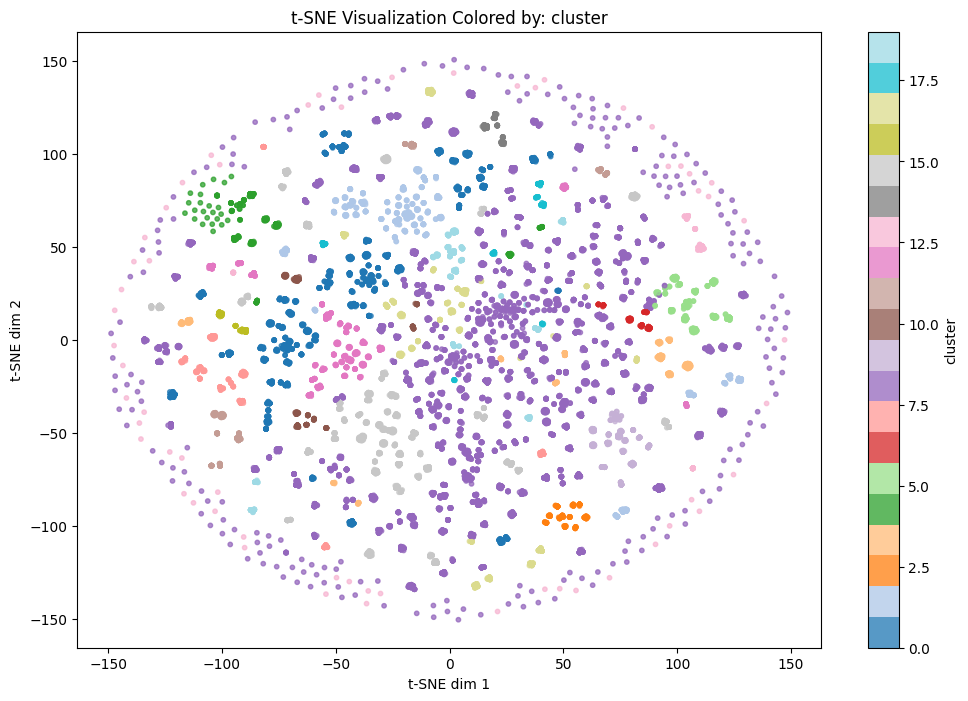

In [37]:
def compute_tsne(embeddings, perplexity=30, random_state=42):
    """
    Compute 2D t-SNE projection for visualization.
    embeddings: numpy array of shape (N, D)
    """
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate='auto',
        init='random',
        random_state=random_state
    )
    X_tsne = tsne.fit_transform(embeddings)
    return X_tsne


X_tsne = compute_tsne(embeddings)
data_pop["tsne_x"] = X_tsne[:, 0]
data_pop["tsne_y"] = X_tsne[:, 1]

def plot_tsne(df, color="cluster", cmap="tab20", size=10):
    plt.figure(figsize=(12, 8))
    sc = plt.scatter(
        df["tsne_x"], df["tsne_y"],
        c=df[color],
        cmap=cmap,
        s=size,
        alpha=0.75
    )
    plt.colorbar(sc, label=color)
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.title(f"t-SNE Visualization Colored by: {color}")
    plt.show()

plot_tsne(data_pop, color="cluster")

In [24]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(embeddings, data_pop["cluster"])
sil_score

0.11966394057273733

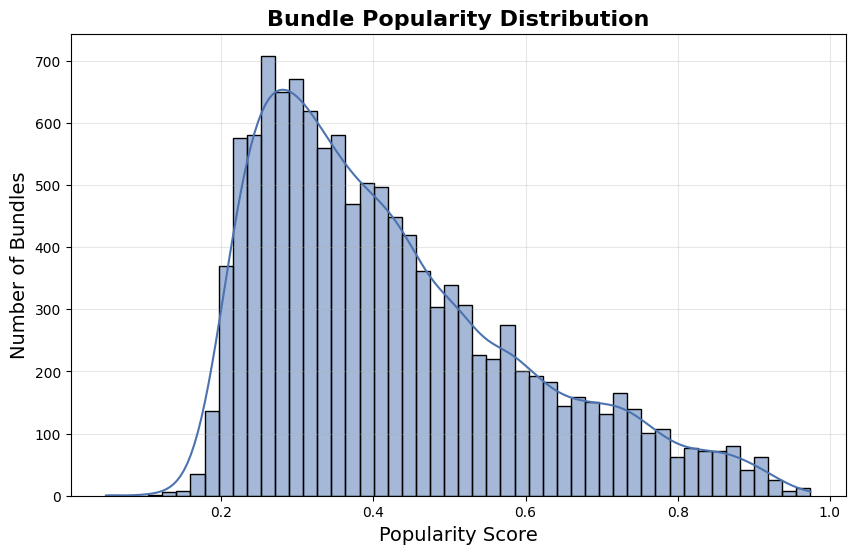

In [25]:
plt.figure(figsize=(10,6))
sns.histplot(data_pop['popularity_score'], bins=50, kde=True, color="#4C72B0", edgecolor='black')
plt.title("Bundle Popularity Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Popularity Score", fontsize=14)
plt.ylabel("Number of Bundles", fontsize=14)
plt.grid(alpha=0.3)
plt.show()


In [26]:
# Detemine the best thresholds based on Gaussian Mixture
scores = data_pop["popularity_score"].values.reshape(-1, 1)

# Fit GMM
gmm = GaussianMixture(n_components=3, random_state=42).fit(scores)
labels = gmm.predict(scores)
probs = gmm.predict_proba(scores)
means = gmm.means_.flatten()
std_devs = np.sqrt(gmm.covariances_.flatten())
weights = gmm.weights_.flatten()

# Sort components by mean
order = np.argsort(means)
means = means[order]
std_devs = std_devs[order]
weights = weights[order]

thresholds = np.sort(gmm.means_.flatten())
print("derived thresholds:", thresholds)

derived thresholds: [0.28776005 0.45974159 0.7099638 ]


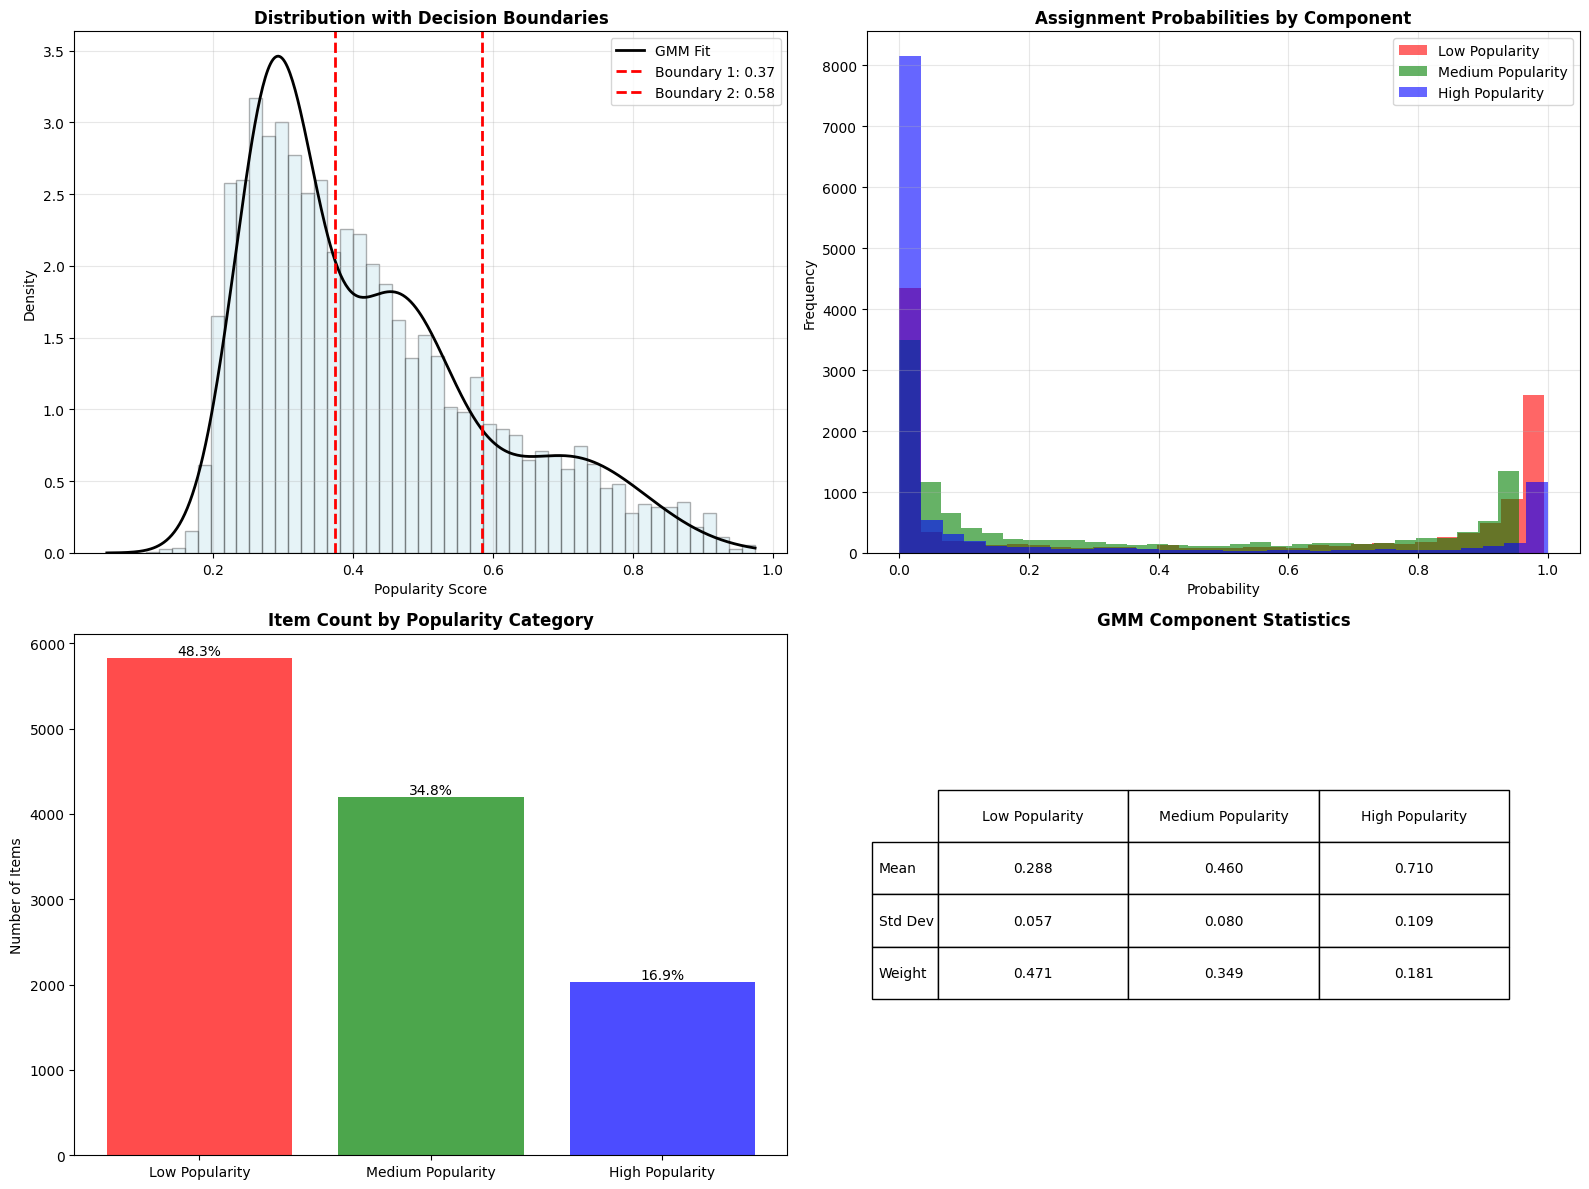

In [27]:
# Plot 1: Distribution with individual components
x_axis = np.linspace(scores.min(), scores.max(), 500).reshape(-1, 1)
logprob = gmm.score_samples(x_axis)
pdf = np.exp(logprob)

colors = ['red', 'green', 'blue']
component_names = ['Low Popularity', 'Medium Popularity', 'High Popularity']

thresholds = []
for i in range(len(means)-1):
    threshold = (means[i] + means[i+1]) / 2
    thresholds.append(threshold)

# Create comprehensive figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Enhanced distribution with decision boundaries
ax1.hist(scores, bins=50, alpha=0.3, density=True, color='lightblue', edgecolor='black')
ax1.plot(x_axis, pdf, 'k-', linewidth=2, label='GMM Fit')

# Add decision boundaries
for i, threshold in enumerate(thresholds):
    ax1.axvline(threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Boundary {i+1}: {threshold:.2f}')

ax1.set_title('Distribution with Decision Boundaries', fontweight='bold')
ax1.set_xlabel('Popularity Score')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Component probabilities
for i, (color, name) in enumerate(zip(colors, component_names)):
    ax2.hist(probs[:, order[i]], bins=30, alpha=0.6, color=color, label=name)
ax2.set_title('Assignment Probabilities by Component', fontweight='bold')
ax2.set_xlabel('Probability')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Summary statistics
categories = component_names
counts = [np.sum(labels == order[i]) for i in range(3)]
percentages = [count/len(scores)*100 for count in counts]

bars = ax3.bar(categories, counts, color=colors, alpha=0.7)
ax3.set_title('Item Count by Popularity Category', fontweight='bold')
ax3.set_ylabel('Number of Items')

# Add percentage labels on bars
for bar, percentage in zip(bars, percentages):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{percentage:.1f}%', ha='center', va='bottom')

# Plot 4: Statistical summary
stats_data = {
    'Mean': means,
    'Std Dev': std_devs,
    'Weight': weights
}

ax4.axis('off')
table_data = [[f'{val:.3f}' for val in stats_data[key]] for key in stats_data]
table = ax4.table(cellText=table_data,
                  rowLabels=list(stats_data.keys()),
                  colLabels=component_names,
                  cellLoc='center',
                  loc='center',
                  bbox=[0.1, 0.3, 0.8, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
ax4.set_title('GMM Component Statistics', fontweight='bold')

plt.tight_layout()
plt.show()

In [28]:
data.loc[:, 'popularity'] = data_pop['popularity_score'].values

In [29]:
threshold_low = (means[0] + means[1]) / 2   # midpoint between first and second mean
threshold_high = (means[1] + means[2]) / 2  # midpoint between second and third mean

print("Thresholds for categories:", threshold_low, threshold_high)

def gmm_category(score):
    if score < threshold_low:
        return "unpopular"
    elif score < threshold_high:
        return "popular"
    else:
        return "very popular"
    
data["popularity_category"] = data["popularity"].apply(gmm_category)
data["popularity_category"].value_counts()

Thresholds for categories: 0.373750821928225 0.5848526952007407


popularity_category
unpopular       5768
popular         4095
very popular    2194
Name: count, dtype: int64

In [30]:
data.sort_values(by='popularity', ascending=False)

,month_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,total_sessions,unique_users,season,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,popularity,popularity_category
10043,9,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,7.981991e+08,3990997,3990997,743952,Autumn,0.00,16.0,0.0,1 days,24.0,0.974595,very popular
9291,8,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,7.970734e+08,3985370,3985370,729903,Summer,0.00,16.0,0.0,1 days,24.0,0.974245,very popular
11385,10,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,7.736132e+08,3868077,3868077,746984,Autumn,0.00,16.0,0.0,1 days,24.0,0.973446,very popular
7372,7,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,7.840630e+08,3920326,3920326,709883,Summer,0.00,16.0,0.0,1 days,24.0,0.973175,very popular
6818,6,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,7.067377e+08,3533689,3533689,658232,Summer,0.00,16.0,0.0,1 days,24.0,0.967977,very popular
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8301,7,2025,37340,Forfait jeu video 7 jours@1000F,BUNDLE_DATA,1000.0,CHARGED,PREPAID,1.000000e+00,1,1,1,Summer,32399.36,0.0,0.0,7 days,168.0,0.127935,unpopular
6196,6,2025,80092,Forfait 16Min vers Autres (+2min vers MTN) 3 J...,BUNDLE_VOICE,300.0,CHARGED,STAFF,1.000000e+00,1,1,1,Summer,0.00,19.0,0.0,3 days,72.0,0.123924,unpopular
6774,6,2025,80094,Forfait 50Min vers Autres (+4min vers MTN) 15 ...,BUNDLE_VOICE,775.0,CHARGED,STAFF,1.000000e+00,1,1,1,Summer,0.00,50.0,0.0,15 days,360.0,0.123499,unpopular
11506,10,2025,CLOUDPBX224MN5742F,Voice Bundle 31 Days @5742F 224min,BUNDLE_VOICE,5742.0,CHARGED,PREPAID,0.000000e+00,2,2,1,Autumn,0.00,224.0,0.0,31 days,744.0,0.109901,unpopular


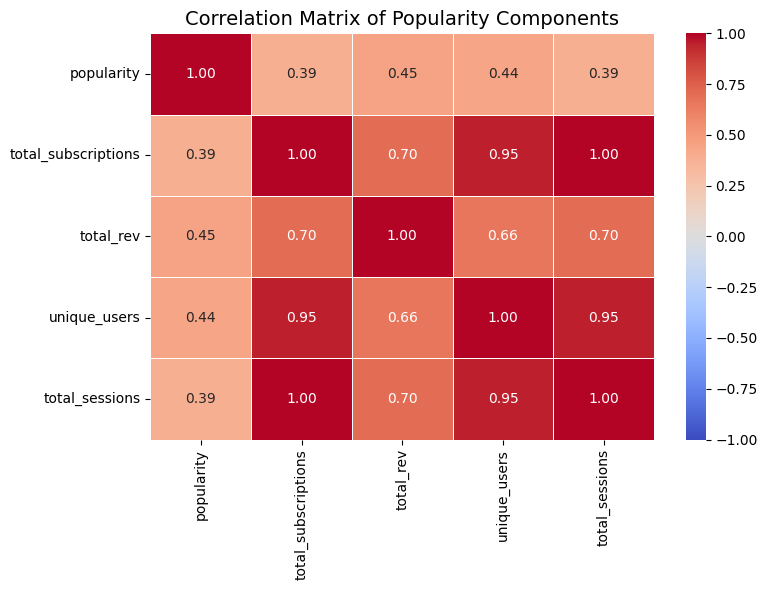

In [31]:
corr = data[['popularity','total_subscriptions','total_rev','unique_users','total_sessions']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,        
    cmap="coolwarm",  
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Popularity Components", fontsize=14)
plt.tight_layout()
plt.show()

In [39]:
import plotly.express as px

fig = px.scatter_3d(
    data,
    x='total_subscriptions',
    y='total_rev',
    z='popularity',
    color='unique_users',
    size='unique_users',
    hover_name='bundle_name'
)

fig.show()

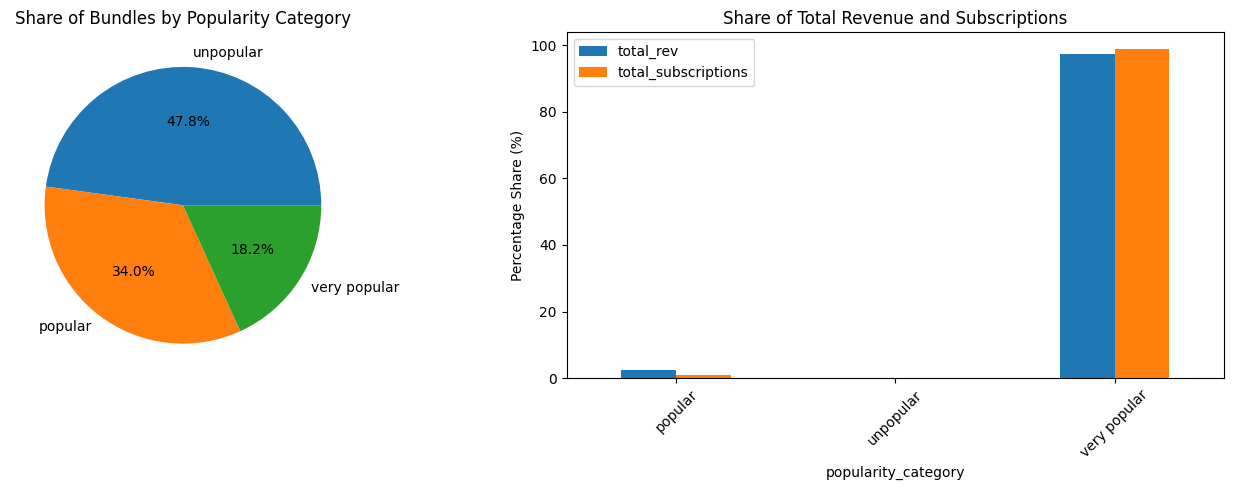

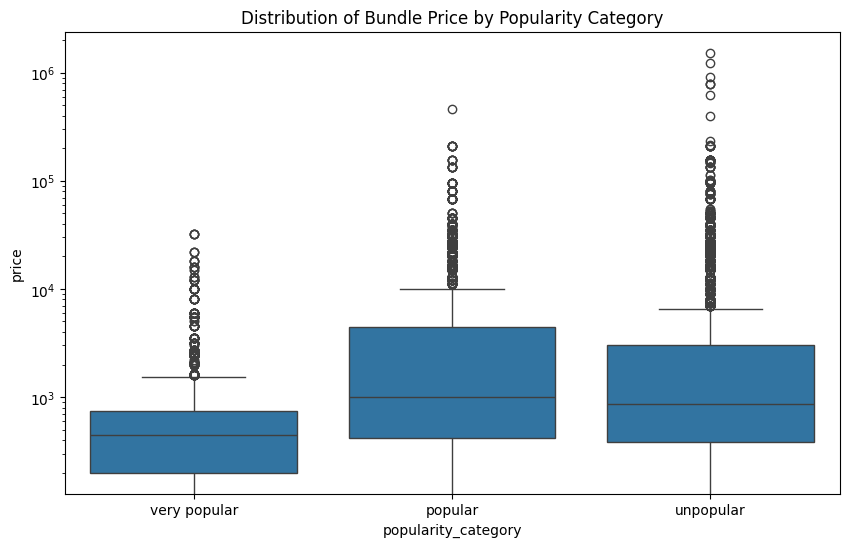

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

data['popularity_category'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax1, title='Share of Bundles by Popularity Category')
ax1.set_ylabel('')

summary_df = data.groupby('popularity_category').agg({
    'total_rev': 'sum',
    'total_subscriptions': 'sum'
}).apply(lambda x: 100 * x / x.sum()) 

summary_df.plot.bar(ax=ax2, title='Share of Total Revenue and Subscriptions')
ax2.set_ylabel('Percentage Share (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='popularity_category', y='price')
plt.yscale('log') 
plt.title('Distribution of Bundle Price by Popularity Category')
plt.show()

In [33]:
data

,month_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,total_sessions,unique_users,season,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,popularity,popularity_category
0,1,2025,FVX7D840FV3,Maxivoice 90Mins 7 jour@840F,BUNDLE_VOICE,840.0,CHARGED,PREPAID,94717559.86,112759,112759,33989,Winter,0.0,90.0,0.0,7 days,168.0,0.810998,very popular
2,1,2025,36848,Zone A and B NDAKO 550GB 30 Jours@26500F,BUNDLE_DATA,26500.0,CHARGED,PREPAID,2782500.00,105,105,105,Winter,563200.0,0.0,0.0,30 days,720.0,0.487039,popular
3,1,2025,FVX1D120F,"Maxivoice 7,5Mins and 1,5Mins 1 jour@120F",BUNDLE_VOICE,120.0,CHARGED,HYBRID,480.00,4,4,1,Winter,0.0,9.0,0.0,1 days,24.0,0.216602,unpopular
5,1,2025,36206,Forfait Classic 7 jours 375MB@1200,BUNDLE_DATA,1200.0,CHARGED,HYBRID,22800.00,19,19,12,Winter,375.0,0.0,0.0,7 days,168.0,0.361935,unpopular
6,1,2025,ALLNET10MN1D450F,Forfait MagicVoice tous reseaux 1 jour 10 mins...,BUNDLE_VOICE,450.0,CHARGED,HYBRID,1350.00,3,3,3,Winter,0.0,0.0,0.0,1 days,24.0,0.246854,unpopular
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12307,10,2025,36207,Forfait Classic 7 jours 750MB@2000,BUNDLE_DATA,2000.0,CHARGED,PREPAID,70000.00,35,35,21,Autumn,750.0,0.0,0.0,7 days,168.0,0.406896,popular
12308,10,2025,36972,MagicNet 20.2GB 30 Jours@13000F,BUNDLE_DATA,13000.0,CHARGED,HYBRID,364000.00,28,28,28,Autumn,20684.8,0.0,0.0,30 days,720.0,0.431285,popular
12309,10,2025,35074,Forfait 1 jour 28 MB,BUNDLE_DATA,130.0,CHARGED,PREPAID,1604070.00,13426,13473,8878,Autumn,28.0,0.0,0.0,1 days,24.0,0.691410,very popular
12310,10,2025,80141,Forfait Chrono voice 40 Mins 4H@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,4375517.00,22162,22795,10990,Autumn,0.0,40.0,0.0,4 hours,4.0,0.723805,very popular


## Popularity Regression Model 

In [43]:
X = data[
    [
        "month_number", "season", "bundle_name", "bundle_type",  "price",
        "usage_type", "service_class_category", "configured_volume_mb",
        "configured_volume_min", "configured_volume_sms", "validity_hours"
    ]
].copy()
 
y = data["popularity"].astype(float)

assert len(X) == len(y)

In [44]:
groups = X["bundle_name"]

# Create the group-based split
gss = GroupShuffleSplit(n_splits=1, test_size=0.05, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)

# Optional: check
print("Training bundles:", X_train["bundle_name"].nunique())
print("Testing bundles:", X_test["bundle_name"].nunique())
print("Overlap:", len(set(X_train["bundle_name"]) & set(X_test["bundle_name"])))

Training bundles: 989
Testing bundles: 53
Overlap: 0


In [45]:
def feature_engineering_data(df, y):
    df = df.copy()

    cat_cols = ["season", "bundle_type", "usage_type", "service_class_category"]

    # Target encoding
    te = TargetEncoder()
    df_encoded = df.copy()
    df_encoded[cat_cols] = te.fit_transform(df[cat_cols], y)

    # Better embedding: Sentence Transformer
    st_model = SentenceTransformer("all-MiniLM-L6-v2")
    name_emb = st_model.encode(df["bundle_name"].tolist())

    # Reduce dimension
    pca = PCA(n_components=32)
    name_emb_pca = pca.fit_transform(name_emb)

    # Add embeddings
    for i in range(name_emb_pca.shape[1]):
        df_encoded[f"name_emb_{i}"] = name_emb_pca[:, i]

    # numeric
    numeric_df = df_encoded.select_dtypes(include=[float, int]).copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(numeric_df)

    X_ready = pd.DataFrame(X_scaled, columns=numeric_df.columns)

    return X_ready, te, st_model, pca, scaler


X_train, te, tfidf, pca, scaler = feature_engineering_data(X_train, y_train)
print(X_train.shape)
X_test, te, tfidf, pca, scaler = feature_engineering_data(X_test, y_test)
print(X_test.shape)

(11422, 42)
(635, 42)


In [46]:
X_train

,month_number,season,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity_hours,...,name_emb_22,name_emb_23,name_emb_24,name_emb_25,name_emb_26,name_emb_27,name_emb_28,name_emb_29,name_emb_30,name_emb_31
0,-1.621027,-1.806054,0.304195,-0.167814,-0.176753,0.675107,-0.170149,0.568250,-0.089161,-0.311156,...,0.210142,0.193397,-0.537264,0.679341,0.683272,0.420535,0.337522,0.395371,-0.066391,-0.125488
1,-1.621027,-1.699730,0.323956,0.706312,0.087081,0.720068,5.610122,-0.283232,-0.089161,1.346945,...,-1.494446,-1.171534,0.925708,1.555531,-1.072529,-0.495324,0.506173,-1.203536,1.654367,-0.425200
2,-1.621027,-1.699730,0.400239,-0.192342,0.087081,-1.038850,-0.170149,-0.198084,-0.089161,-0.743704,...,-0.524699,-2.210349,-0.089211,0.441295,0.411948,0.044462,-1.141379,-0.806346,-0.043578,-0.227777
3,-1.621027,-1.806054,0.277222,-0.155551,-0.176753,-1.035988,-0.166300,-0.283232,-0.089161,-0.311156,...,-1.222923,-1.864048,-0.400463,-0.093957,0.617075,0.441165,0.605915,0.523151,-0.686128,-0.337281
4,-1.621027,-1.699730,0.400239,-0.181100,0.087081,-1.038850,-0.170149,-0.283232,-0.089161,-0.743704,...,2.567846,0.053403,1.029026,0.250709,0.705582,1.140009,-0.222428,-0.406964,0.790885,1.421757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11417,1.549233,0.660146,0.254262,-0.128298,0.086300,0.722824,-0.162452,-0.283232,-0.089161,-0.311156,...,-1.324570,-1.444224,0.522912,-0.496893,-0.330375,0.616203,0.694970,1.297915,-0.702862,0.682783
11418,1.549233,1.901879,0.277222,0.246425,-0.176753,-1.035988,0.042144,-0.283232,-0.089161,1.346945,...,0.939789,0.481348,0.241208,0.083555,1.241805,0.768276,0.118764,0.535598,-0.742537,-1.141299
11419,1.549233,0.660146,0.254262,-0.192001,0.086300,0.722824,-0.169862,-0.283232,-0.089161,-0.743704,...,-0.642743,-0.535767,0.599203,-0.134518,-1.053327,1.328764,-0.726128,-1.319590,-0.261711,2.939487
11420,1.549233,0.660146,0.356721,-0.189616,0.086300,0.722824,-0.170149,0.095205,-0.089161,-0.803780,...,0.085258,0.896229,1.826479,0.029976,1.225132,-0.004849,-0.308216,-0.360289,-2.268478,0.072993


In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=250, max_depth=12, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42
    ),
    "AdaBoost": AdaBoostRegressor(n_estimators=200, random_state=42),
    "SVR (RBF Kernel)": SVR(C=2.0, epsilon=0.1),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=7),
    "LGBMRegressor": lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42
),
}

results = []

for name, model in tqdm(models.items(), total=len(models)):

    if name in ["Linear Regression", "Ridge Regression", "Lasso Regression",
                "SVR (RBF Kernel)", "KNN Regressor", "LGBMRegressor"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    evs = explained_variance_score(y_test, y_pred)

    results.append([
        name, rmse, mae, mape, r2, evs, 
    ])


results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "MAE", "MAPE", "R2", "Explained Variance"]
)

results_df = results_df.sort_values("RMSE")
results_df

 80%|████████  | 8/10 [00:49<00:11,  5.72s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001010 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8848
[LightGBM] [Info] Number of data points in the train set: 11422, number of used features: 42
[LightGBM] [Info] Start training from score 0.422970


100%|██████████| 10/10 [00:49<00:00,  4.95s/it]


,Model,RMSE,MAE,MAPE,R2,Explained Variance
6,AdaBoost,0.152669,0.117037,0.311957,0.319282,0.319304
4,Random Forest,0.160217,0.122591,0.322427,0.250309,0.253879
5,Gradient Boosting,0.167304,0.128976,0.331939,0.182522,0.196635
9,LGBMRegressor,0.167714,0.127369,0.318375,0.178510,0.199118
2,Lasso Regression,0.171340,0.129563,0.331879,0.142599,0.153619
8,KNN Regressor,0.173372,0.124826,0.304022,0.122142,0.133659
1,Ridge Regression,0.174546,0.133065,0.342801,0.110212,0.121232
0,Linear Regression,0.174550,0.133068,0.342811,0.110179,0.121199
3,Decision Tree,0.191239,0.146470,0.403156,-0.068118,-0.055385
7,SVR (RBF Kernel),0.215726,0.172895,0.448804,-0.359162,-0.224646


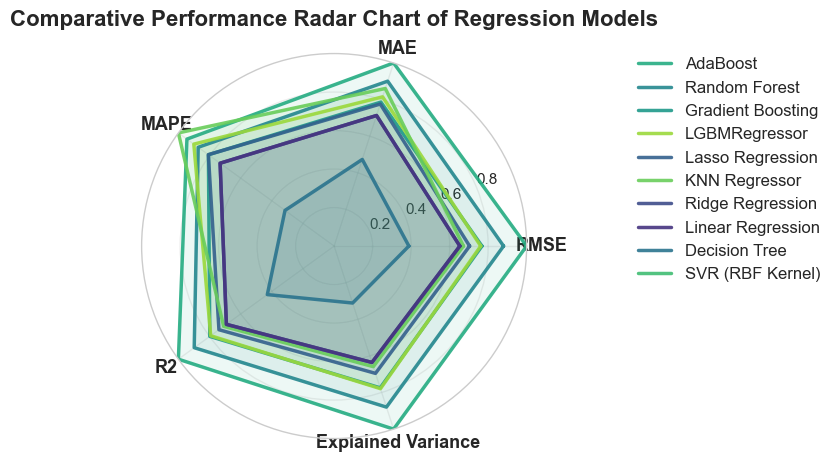

In [48]:
df = results_df.copy()
higher_better = ["R2", "Explained Variance"]
lower_better = ["RMSE", "MAE", "MAPE"]

for col in higher_better:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

for col in lower_better:
    df[col] = 1 - (df[col] - df[col].min()) / (df[col].max() - df[col].min())

metrics = ["RMSE", "MAE", "MAPE", "R2", "Explained Variance"]
labels = metrics
num_metrics = len(metrics)

angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]   

plt.figure(figsize=(5, 5))
plt.style.use("seaborn-v0_8-whitegrid")

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(df)))

for i, row in df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]   

    plt.polar(
        angles,
        values,
        label=row["Model"],
        linewidth=2.5,
        alpha=0.9,
        color=colors[i]
    )

    plt.fill(angles, values, alpha=0.08, color=colors[i])

plt.xticks(angles[:-1], labels, fontsize=13, fontweight="bold")

plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], fontsize=11)
plt.ylim(0, 1)

plt.title(
    "Comparative Performance Radar Chart of Regression Models",
    fontsize=16,
    fontweight="bold",
    pad=20
)
plt.legend(
    bbox_to_anchor=(1.25, 1.03),
    frameon=False,
    fontsize=12
)
plt.grid(alpha=0.35, linewidth=1)

plt.show()

## Popularity Classifier Model 

In [49]:
X = data[
    [
        "month_number", "season", "bundle_name", "bundle_type",  "price",
        "usage_type", "service_class_category", "configured_volume_mb",
        "configured_volume_min", "configured_volume_sms", "validity_hours"
    ]
].copy()
 
y = data["popularity_category"].astype(str)

assert len(X) == len(y)

In [50]:
groups = X["bundle_name"]

# Create the group-based split (90% train, 10% test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)

# Optional: check
print("Training bundles:", X_train["bundle_name"].nunique())
print("Testing bundles:", X_test["bundle_name"].nunique())
print("Overlap:", len(set(X_train["bundle_name"]) & set(X_test["bundle_name"])))

Training bundles: 937
Testing bundles: 105
Overlap: 0


In [52]:
num_cols = ["month_number", "price", "configured_volume_mb", 
            "configured_volume_min", "configured_volume_sms", "validity_hours"]


cat_cols = ["season", "bundle_type", "usage_type", "service_class_category"]
df_encoded = X_train.copy()
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_encoded[cat_cols] = encoder.fit_transform(df_encoded[cat_cols])

# Sentence Transformer embeddings
st_model = SentenceTransformer("all-MiniLM-L6-v2")
name_emb = st_model.encode(df_encoded["bundle_name"].tolist())

# PCA on embeddings
pca = PCA(n_components=16)
name_emb_pca = pca.fit_transform(name_emb)

# Add PCA components as features
for i in range(name_emb_pca.shape[1]):
    df_encoded[f"name_emb_{i}"] = name_emb_pca[:, i]

# Scale numeric features
numeric_df = df_encoded.select_dtypes(include=[float, int]).copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)
X_train_ready = pd.DataFrame(X_scaled, columns=numeric_df.columns)

# Transform test data using **trained encoders/scalers/PCA**
df_test_encoded = X_test.copy()
df_test_encoded[cat_cols] = encoder.transform(df_test_encoded[cat_cols])

# Bundle name embeddings for test set
name_emb_test = st_model.encode(df_test_encoded["bundle_name"].tolist())
name_emb_test_pca = pca.transform(name_emb_test)
for i in range(name_emb_test_pca.shape[1]):
    df_test_encoded[f"name_emb_{i}"] = name_emb_test_pca[:, i]

numeric_df_test = df_test_encoded.select_dtypes(include=[float, int]).copy()
X_test_ready = pd.DataFrame(scaler.transform(numeric_df_test), columns=numeric_df_test.columns)

In [53]:
clf = HistGradientBoostingClassifier(
    max_iter=500,
    max_depth=10,
    learning_rate=0.05,
    l2_regularization=0.3,
    class_weight='balanced',  # boosts rare classes
    random_state=42
)
clf.fit(X_train_ready, y_train)

# Evaluate
y_pred = clf.predict(X_test_ready)
rr = classification_report(y_test, y_pred)
print(rr)

              precision    recall  f1-score   support

     popular       0.62      0.55      0.58       444
   unpopular       0.69      0.84      0.76       528
very popular       0.68      0.54      0.60       280

    accuracy                           0.67      1252
   macro avg       0.66      0.64      0.65      1252
weighted avg       0.66      0.67      0.66      1252



In [60]:
def predict_bundle_class(new_bundle, encoder, st_model, pca, scaler, clf):
    """
    Predict popularity category for a new bundle.
    
    Parameters
    ----------
    new_bundle : dict or pandas.DataFrame
        The new bundle's feature values.
    encoder : OrdinalEncoder
        Fitted ordinal encoder for categorical features.
    st_model : SentenceTransformer
        Fitted sentence-transformer model.
    pca : PCA
        Fitted PCA transformer for name embeddings.
    scaler : StandardScaler
        Fitted scaler for numeric + embedding features.
    clf : HistGradientBoostingClassifier
        Trained classifier.

    Returns
    -------
    str
        Predicted popularity class.
    """
    if isinstance(new_bundle, dict):
        df_new = pd.DataFrame([new_bundle])
    else:
        df_new = new_bundle.copy()

    cat_cols = ["season", "bundle_type", "usage_type", "service_class_category"]
    num_cols = [
        "month_number", "price", "configured_volume_mb",
        "configured_volume_min", "configured_volume_sms", "validity_hours"
    ]
    df_new[cat_cols] = encoder.transform(df_new[cat_cols])

    name_emb = st_model.encode(df_new["bundle_name"].tolist())
    name_emb_pca = pca.transform(name_emb)

    for i in range(name_emb_pca.shape[1]):
        df_new[f"name_emb_{i}"] = name_emb_pca[:, i]
    numeric_df = df_new[[col for col in df_new.columns if df_new[col].dtype != "object"]].copy()
    X_scaled = scaler.transform(numeric_df)
    pred = clf.predict(X_scaled)[0]
    return pred



new_bundle = {
    "month_number": 5,
    "season": "summer",
    "bundle_name": "Mega Social Plus",
    "bundle_type": "data",
    "price": 30.5,
    "usage_type": "youth",
    "service_class_category": "prepaid",
    "configured_volume_mb": 1500,
    "configured_volume_min": 30,
    "configured_volume_sms": 50,
    "validity_hours": 72
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: popular


In [61]:
new_bundle = {
    "month_number": 1,
    "season": "Summer",
    "bundle_name": "Maxivoice 19Mins jour@220F",
    "bundle_type": "BUNDLE_VOICE",
    "price": 220.0,
    "usage_type": "CHARGED",
    "service_class_category": "PREPAID",
    "configured_volume_mb": 0.0,
    "configured_volume_min": 19.0,
    "configured_volume_sms": 0.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: very popular


In [62]:
new_bundle = {
    "month_number": 1,
    "season": "Summer",
    "bundle_name": "Maxivoice 19Mins 1000MB jour@2000F",
    "bundle_type": "BUNDLE_VOICE",
    "price": 2000.0,
    "usage_type": "CHARGED",
    "service_class_category": "PREPAID",
    "configured_volume_mb": 0.0,
    "configured_volume_min": 19.0,
    "configured_volume_sms": 1000.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: very popular


In [63]:
new_bundle = {
    "month_number": 1,
    "season": "Summer",
    "bundle_name": "Zone A and B NDAKO  550GB  30 Jours@26500F",
    "bundle_type": "BUNDLE_DATA",
    "price": 26500.0,
    "usage_type": "CHARGED",
    "service_class_category": "PREPAID",
    "configured_volume_mb": 0.0,
    "configured_volume_min": 19.0,
    "configured_volume_sms": 0.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: popular


In [64]:
new_bundle = {
    "month_number": 1,
    "season": "Winter",
    "bundle_name": "Forfait weekend 780MB 1jours@350F",
    "bundle_type": "BUNDLE_DATA",
    "price": 350.0,
    "usage_type": "CHARGED",
    "service_class_category": "PREPAID",
    "configured_volume_mb": 780.0,
    "configured_volume_min": 0.0,
    "configured_volume_sms": 0.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: very popular


In [65]:

new_bundle = {
    "month_number": 1,
    "season": "Winter",
    "bundle_name": "Forfait weekend 780MB 1jours@350F",
    "bundle_type": "BUNDLE_DATA",
    "price": 350.0,
    "usage_type": "CHARGED",
    "service_class_category": "STAFF",
    "configured_volume_mb": 780.0,
    "configured_volume_min": 0.0,
    "configured_volume_sms": 0.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: unpopular


In [58]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(random_state=1, max_iter=300).fit(X_train_ready, y_train)
mlp.fit(X_train_ready, y_train)

# Evaluate
y_pred = mlp.predict(X_test_ready)
rr = classification_report(y_test, y_pred)
print(rr)

              precision    recall  f1-score   support

     popular       0.59      0.57      0.58       444
   unpopular       0.67      0.79      0.73       528
very popular       0.74      0.53      0.62       280

    accuracy                           0.65      1252
   macro avg       0.67      0.63      0.64      1252
weighted avg       0.66      0.65      0.65      1252



In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(max_depth=25, random_state=0).fit(X_train_ready, y_train)
rf.fit(X_train_ready, y_train)

# Evaluate
y_pred = rf.predict(X_test_ready)
rr = classification_report(y_test, y_pred)
print(rr)

              precision    recall  f1-score   support

     popular       0.64      0.52      0.58       444
   unpopular       0.67      0.87      0.76       528
very popular       0.74      0.54      0.62       280

    accuracy                           0.67      1252
   macro avg       0.68      0.64      0.65      1252
weighted avg       0.68      0.67      0.66      1252

